# 🛰️ OSINT Intelligence — Vectorización de Noticias y Detección de Patrones

**Objetivo:** Aplicar procesamiento de lenguaje natural (NLP) sobre las noticias recolectadas de fuentes OSINT para identificar agrupaciones temáticas que revelen patrones de comportamiento en el conflicto **Irán – Israel – EE.UU.**

**Pipeline:**
1. 📦 Carga de artículos desde la base de datos local
2. 🧹 Preprocesamiento y construcción del corpus
3. 📐 Vectorización con **TF-IDF**
4. 📊 Selección del número óptimo de clusters (Codo + Silhouette)
5. 🔵 Clustering con **KMeans**
6. 🗺️ Reducción de dimensionalidad con **PCA** y visualización
7. 📋 Exportación de resultados

## 0. Configuración e Imports

In [1]:
import os
import sys
import datetime
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Apuntamos al directorio raíz del proyecto para importar src.db
PROJECT_ROOT = os.path.dirname(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.db import get_session, NewsArticle

# Intentar cargar UMAP (opcional, mejor visualización que PCA)
try:
    from umap import UMAP
    USE_UMAP = True
    print("✅ UMAP disponible. Se usará para la reducción final.")
except ImportError:
    USE_UMAP = False
    print("ℹ️  UMAP no instalado. Usando PCA. Instala con: pip install umap-learn")

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print("✅ Librerías cargadas correctamente.")

[AVISO] DATABASE_URL no encontrada en .env. Usando SQLite: C:\Users\Arnold's\Documents\Repositorios Machine Learning\Proyecto final Machine Learning\osint.db
ℹ️  UMAP no instalado. Usando PCA. Instala con: pip install umap-learn
✅ Librerías cargadas correctamente.


## 1. 📦 Carga de Artículos desde la Base de Datos

Se consultan todos los artículos recolectados desde el **1 de enero de 2026**.

In [2]:
session = get_session()

articles = session.query(NewsArticle).filter(
    NewsArticle.published_at >= datetime.datetime(2026, 1, 1)
).all()

session.close()

df = pd.DataFrame({
    'id':           [a.id for a in articles],
    'source':       [a.source or '' for a in articles],
    'title':        [a.title or '' for a in articles],
    'description':  [a.description or '' for a in articles],
    'published_at': [a.published_at for a in articles],
})

print(f"📰 Total artículos cargados: {len(df)}")
df.head()

📰 Total artículos cargados: 1250


,id,source,title,description,published_at
0,1751,GDELT - Unknown,美伊談判之際 伊朗演習臨時關閉霍爾木茲海峽 | 美囯,,2026-02-18 01:00:00
1,1752,GDELT - Unknown,Judge blocks deportation of Palestinian activi...,,2026-02-18 01:00:00
2,1753,GDELT - Unknown,Judge blocks deportation of Palestinian activi...,,2026-02-18 01:00:00
3,1754,GDELT - Unknown,U . S . and Iran hail progress in nuclear talk...,,2026-02-18 01:00:00
4,1755,GDELT - Unknown,"Khamenei Threatens American Troops , Attacks I...",,2026-02-18 01:00:00


### Distribución de fuentes

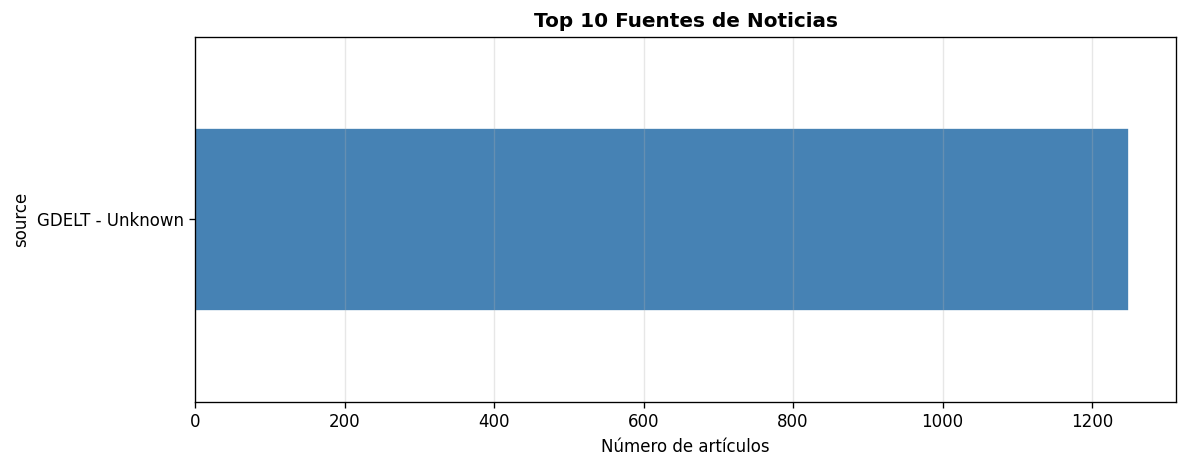

In [3]:
source_counts = df['source'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
source_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Fuentes de Noticias', fontweight='bold')
ax.set_xlabel('Número de artículos')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 🧹 Preprocesamiento del Corpus

Combinamos **título** y **descripción** en un único campo de texto, normalizamos a minúsculas y filtramos artículos con texto insuficiente.

In [4]:
df['text'] = df['title'].str.strip() + ' ' + df['description'].str.strip()
df['text'] = df['text'].str.lower()

# Filtrar artículos con texto muy corto (< 20 caracteres)
df = df[df['text'].str.len() > 20].reset_index(drop=True)

print(f"📄 Artículos con texto válido: {len(df)}")
print(f"📏 Longitud media del texto: {df['text'].str.len().mean():.0f} caracteres")

# Muestra del corpus
df[['source', 'title', 'published_at']].sample(5)

📄 Artículos con texto válido: 1235
📏 Longitud media del texto: 71 caracteres


,source,title,published_at
432,GDELT - Unknown,Ley de Glaciares : la escasez de agua no es so...,2026-02-24 22:15:00
787,GDELT - Unknown,Lo spettro della recessione Linflazione è una ...,2026-04-08 01:00:00
1098,GDELT - Unknown,Economic Fury : US sanctions Iran 35,2026-04-29 00:45:00
906,GDELT - Unknown,"Oil slumps , bonds rally and stocks surge as U...",2026-04-08 01:00:00
636,GDELT - Unknown,Dow Jones dips 34 points as Investors weigh co...,2026-03-11 01:00:00


## 3. 📐 Vectorización con TF-IDF

**TF-IDF** (Term Frequency–Inverse Document Frequency) convierte cada artículo en un vector numérico que pondera:
- **TF**: cuántas veces aparece un término en el artículo.
- **IDF**: qué tan raro es ese término en todo el corpus (penaliza palabras muy comunes).

Usamos **bigramas** (1-2 palabras) para capturar expresiones como *"middle east"* o *"air strike"*.

In [5]:
vectorizer = TfidfVectorizer(
    max_features=500,       # Las 500 palabras/bigramas más relevantes
    stop_words='english',   # Eliminar stopwords en inglés
    ngram_range=(1, 2),     # Unigramas y bigramas
    min_df=2,               # Mínimo 2 documentos para incluir el término
    sublinear_tf=True       # Aplica log(tf+1) para suavizar frecuencias altas
)

X = vectorizer.fit_transform(df['text'])
feature_names = vectorizer.get_feature_names_out()

print(f"✅ Matriz TF-IDF generada:")
print(f"   Artículos (filas): {X.shape[0]}")
print(f"   Términos (columnas): {X.shape[1]}")
print(f"   Sparsidad: {(1 - X.nnz / (X.shape[0] * X.shape[1])):.1%}")

✅ Matriz TF-IDF generada:
   Artículos (filas): 1235
   Términos (columnas): 500
   Sparsidad: 99.1%


### Top términos globales más relevantes

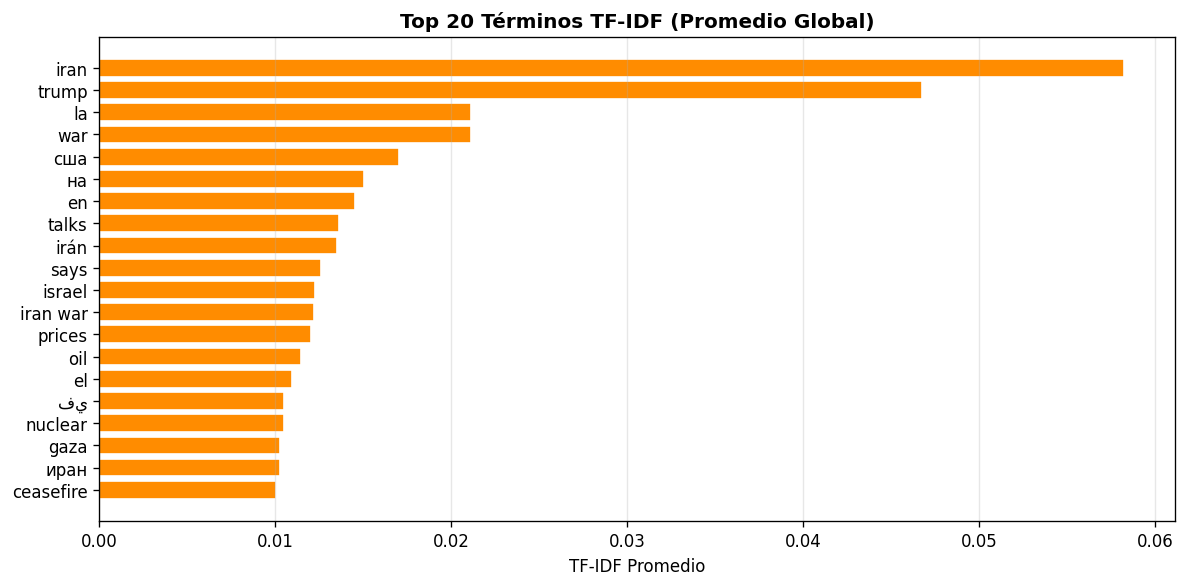

In [6]:
mean_tfidf = np.asarray(X.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:20]
top_terms = pd.DataFrame({'term': feature_names[top_idx], 'mean_tfidf': mean_tfidf[top_idx]})

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_terms['term'][::-1], top_terms['mean_tfidf'][::-1], color='darkorange', edgecolor='white')
ax.set_title('Top 20 Términos TF-IDF (Promedio Global)', fontweight='bold')
ax.set_xlabel('TF-IDF Promedio')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 📊 Selección del Número Óptimo de Clusters

Combinamos dos métricas:
- **Método del Codo**: Buscamos el punto donde la inercia deja de decrecer rápidamente.
- **Coeficiente de Silhouette**: Mide qué tan separados están los clusters (más alto = mejor).

In [7]:
X_dense = X.toarray()
max_k = min(10, len(df) // 5)
k_range = range(2, max_k + 1)

inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_dense)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_dense, labels, sample_size=min(500, len(labels)))
    silhouettes.append(sil)
    print(f"K={k:2d} | Inertia: {km.inertia_:>10.0f} | Silhouette: {sil:.4f}")

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\n✅ Mejor K según Silhouette: {best_k}")

K= 2 | Inertia:        976 | Silhouette: 0.0710
K= 3 | Inertia:        962 | Silhouette: 0.0752


K= 4 | Inertia:        948 | Silhouette: 0.0924
K= 5 | Inertia:        938 | Silhouette: 0.0915


K= 6 | Inertia:        940 | Silhouette: 0.1003


K= 7 | Inertia:        911 | Silhouette: 0.1006


K= 8 | Inertia:        907 | Silhouette: 0.1087


K= 9 | Inertia:        902 | Silhouette: 0.0925


K=10 | Inertia:        899 | Silhouette: 0.1150

✅ Mejor K según Silhouette: 10


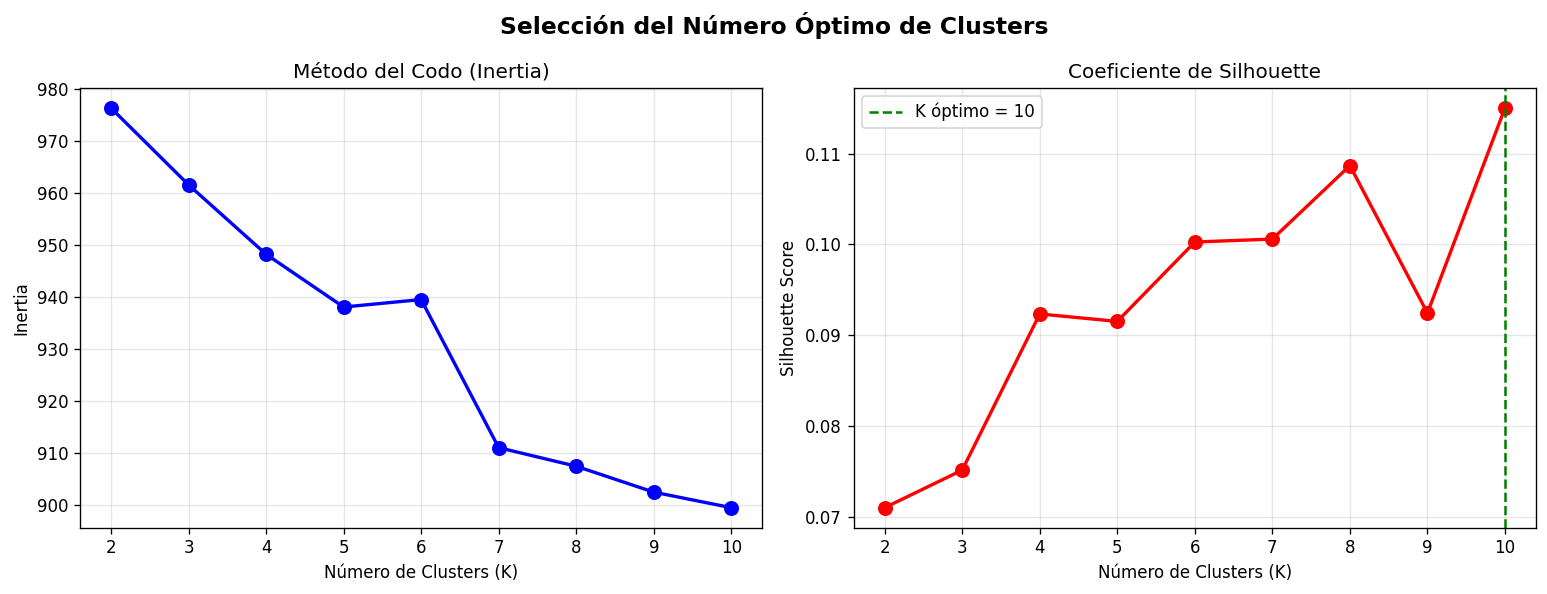

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Selección del Número Óptimo de Clusters', fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo (Inertia)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(best_k, color='green', linestyle='--', label=f'K óptimo = {best_k}')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 🔵 Clustering con KMeans

Aplicamos KMeans con el K óptimo detectado y extraemos las **palabras clave** más representativas de cada cluster (usando los centroides del modelo).

In [9]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_dense)

# Top palabras por cluster (desde los centroides)
order_centroids = km_final.cluster_centers_.argsort()[:, ::-1]
cluster_keywords = {}

print("Top términos por Cluster:\n" + "="*50)
for i in range(best_k):
    top_words = [feature_names[idx] for idx in order_centroids[i, :10]]
    cluster_keywords[i] = top_words
    print(f"Cluster {i}: {', '.join(top_words)}")

print("\nDistribución de artículos por cluster:")
print(df['cluster'].value_counts().sort_index())

Top términos por Cluster:
Cluster 0: δελτίο, ειδήσεων, δελτίο ειδήσεων, 00, iran, trump, la, strait, union, nuclear
Cluster 1: rejects, proposal, trump, iran, от, address, administration, 트럼프, attacks, ataques
Cluster 2: la, irán, en, el, que, los, trump, las, para, guerra
Cluster 3: сша, на, trump, في, gaza, иран, 2026, 國際, ran, israel
Cluster 4: iran, trump, war, talks, iran war, ceasefire, nuclear, says, nuclear talks, progress
Cluster 5: backs kalshi, polymarket, kalshi, kalshi polymarket, backs, polymarket states, states ban, administration backs, ban prediction, prediction
Cluster 6: united states, united, states, iran, az, les, von, il, ginevra, rejects
Cluster 7: highest, highest point, point start, prices reach, reach highest, start iran, start, point, gas prices, gas
Cluster 8: union, state union, state, trump, trump state, expect, president, watch, speech, trump lay
Cluster 9: strait hormuz, hormuz, strait, iran, navy, oil, denies navy, tanker strait, house denies, denies

D

## 6. 🗺️ Reducción de Dimensionalidad y Visualización

La matriz TF-IDF tiene 500 dimensiones. Para visualizarla en 2D usamos:
- **UMAP** (si está instalado): preserva mejor la estructura local de los datos.
- **PCA** (alternativa): más rápido, menos preciso en la separación de clusters.

In [10]:
print(f"Reduciendo dimensiones con {'UMAP' if USE_UMAP else 'PCA'}...")

if USE_UMAP:
    reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    coords = reducer.fit_transform(X_dense)
    dim_label = "UMAP"
else:
    # PCA en 2 pasos: primero a 50 dims, luego a 2
    pca_50 = PCA(n_components=min(50, X_dense.shape[1] - 1), random_state=42)
    X_pca = pca_50.fit_transform(X_dense)
    pca_2 = PCA(n_components=2, random_state=42)
    coords = pca_2.fit_transform(X_pca)
    dim_label = "PCA"

df['x'] = coords[:, 0]
df['y'] = coords[:, 1]
print("✅ Reducción completada.")

Reduciendo dimensiones con PCA...
✅ Reducción completada.


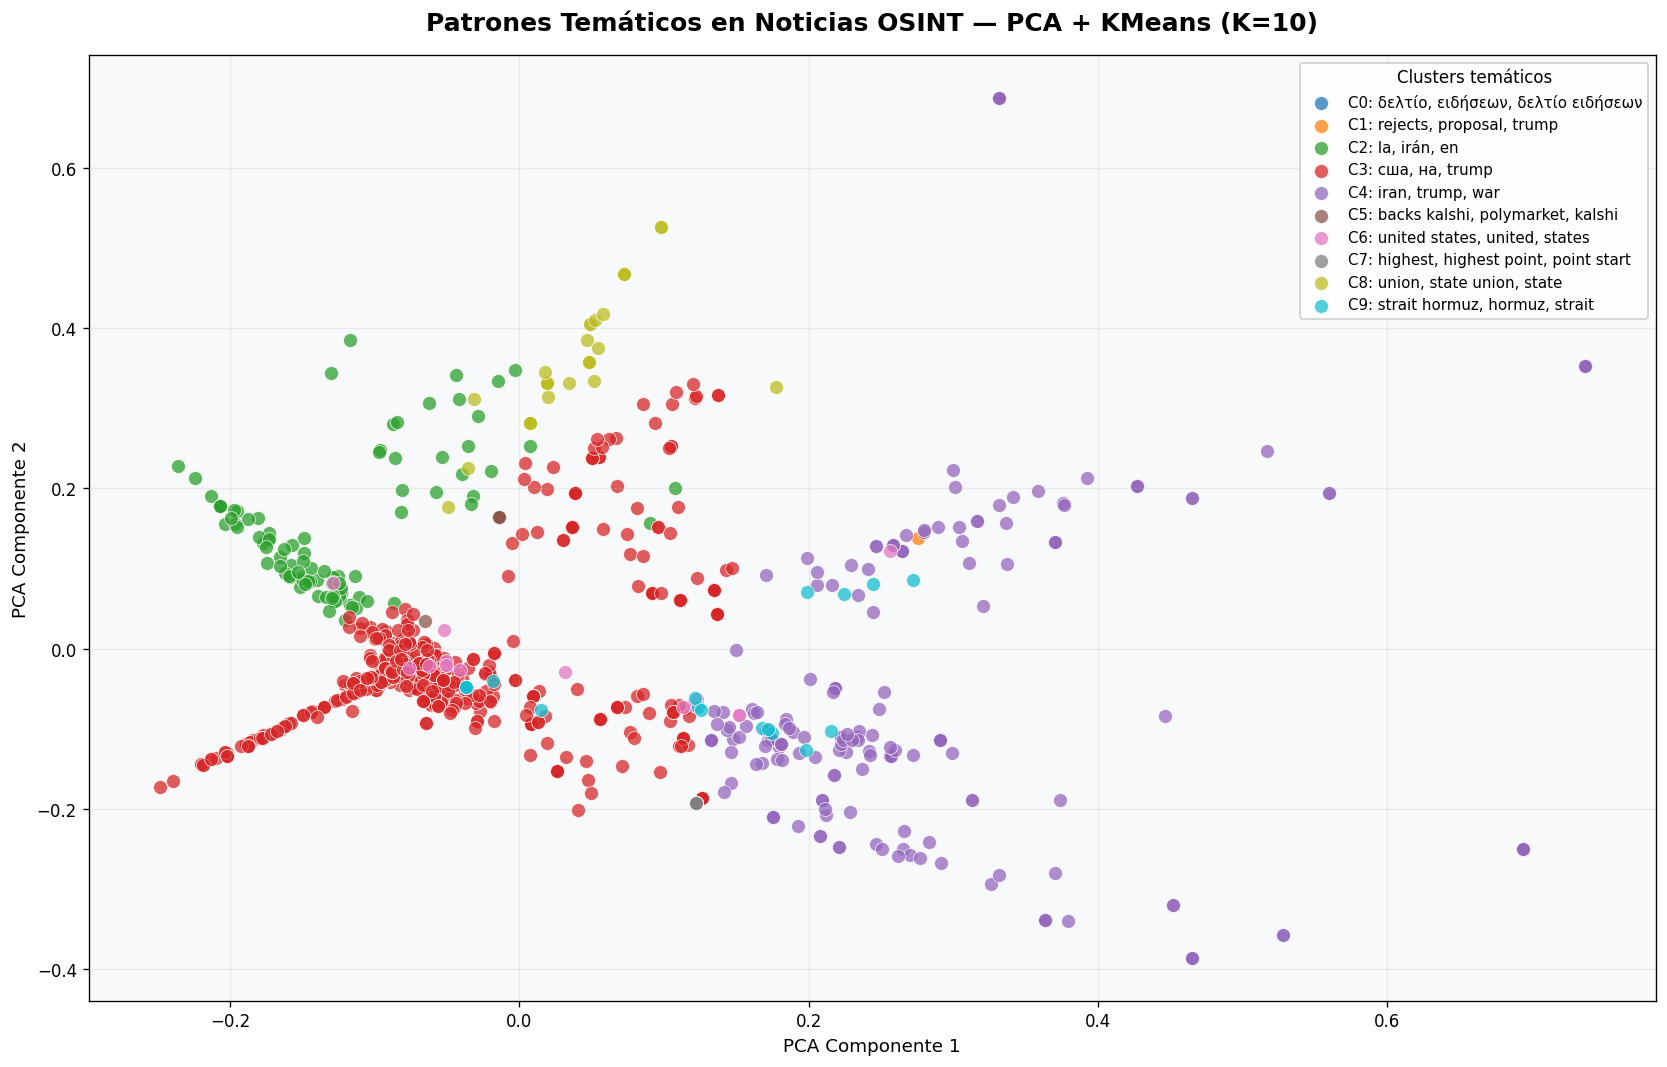

In [11]:
colors = cm.tab10(np.linspace(0, 1, best_k))

fig, ax = plt.subplots(figsize=(14, 9))

for cluster_id in range(best_k):
    mask = df['cluster'] == cluster_id
    label = f"C{cluster_id}: {', '.join(cluster_keywords[cluster_id][:3])}"
    ax.scatter(
        df.loc[mask, 'x'], df.loc[mask, 'y'],
        c=[colors[cluster_id]], label=label,
        alpha=0.75, s=70, edgecolors='white', linewidth=0.5
    )

ax.set_title(f'Patrones Temáticos en Noticias OSINT — {dim_label} + KMeans (K={best_k})',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel(f'{dim_label} Componente 1', fontsize=11)
ax.set_ylabel(f'{dim_label} Componente 2', fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.92, title='Clusters temáticos')
ax.grid(alpha=0.2)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('news_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribución de artículos por cluster

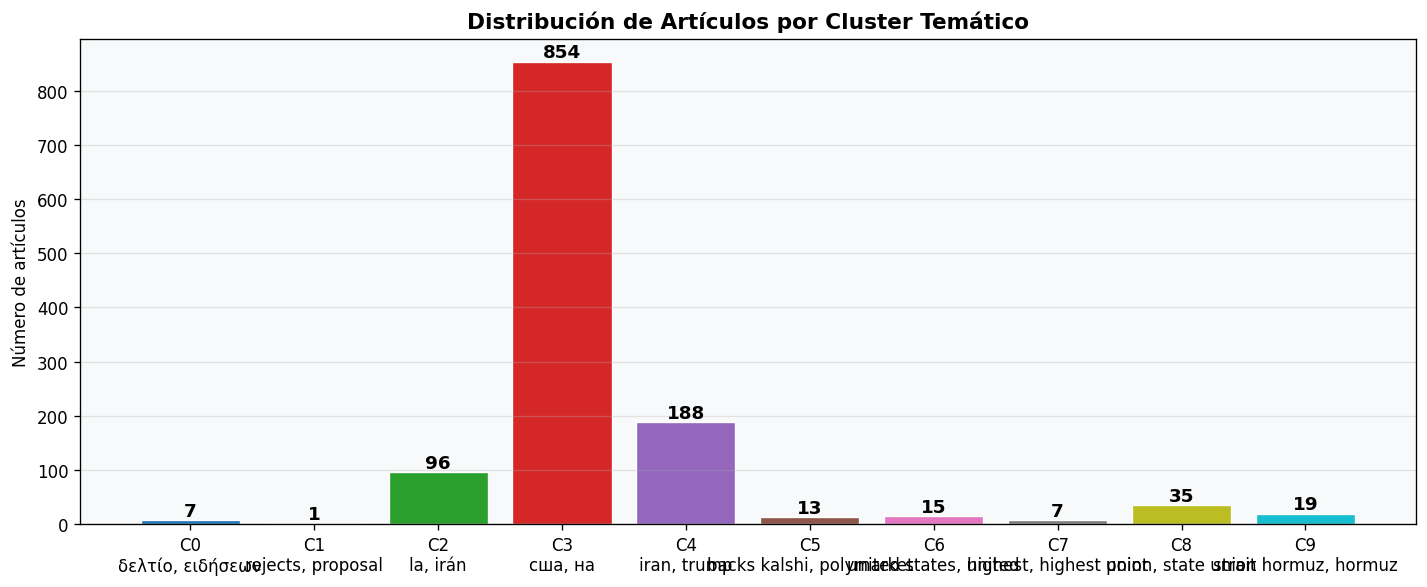

In [12]:
cluster_counts = df['cluster'].value_counts().sort_index()
labels = [f"C{i}\n{', '.join(cluster_keywords[i][:2])}" for i in cluster_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, cluster_counts.values,
              color=[colors[i] for i in cluster_counts.index],
              edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Distribución de Artículos por Cluster Temático', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de artículos')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🔍 Inspección de Artículos por Cluster

Mostramos una muestra de artículos para cada cluster y verificamos la coherencia temática.

In [13]:
for cid in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cid][['source', 'title', 'published_at']]
    print(f"\n{'='*65}")
    print(f"  CLUSTER {cid} — Top temas: {', '.join(cluster_keywords[cid][:5])}")
    print(f"  Total artículos: {len(cluster_df)}")
    print(f"{'='*65}")
    display(cluster_df.head(5))


  CLUSTER 0 — Top temas: δελτίο, ειδήσεων, δελτίο ειδήσεων, 00, iran
  Total artículos: 7


,source,title,published_at
105,GDELT - Unknown,Δελτίο ειδήσεων στις 24 : 00,2026-02-18 00:00:00
115,GDELT - Unknown,Δελτίο ειδήσεων στη 01 : 00,2026-02-18 00:00:00
369,GDELT - Unknown,Δελτίο ειδήσεων στις 24 : 00,2026-02-24 23:45:00
384,GDELT - Unknown,Δελτίο ειδήσεων στη 01 : 00,2026-02-24 23:45:00
1133,GDELT - Unknown,Δελτίο ειδήσεων στις 03 : 00,2026-04-29 00:45:00



  CLUSTER 1 — Top temas: rejects, proposal, trump, iran, от
  Total artículos: 1


,source,title,published_at
310,GDELT - Unknown,What were reading : Student protests continue ...,2026-02-25 00:30:00



  CLUSTER 2 — Top temas: la, irán, en, el, que
  Total artículos: 96


...

,source,title,published_at
988,GDELT - Unknown,Gas prices reach highest point since start of ...,2026-04-29 01:00:00
1003,GDELT - Unknown,Gas prices reach highest point since start of ...,2026-04-29 01:00:00
1014,GDELT - Unknown,Gas prices reach highest point since start of ...,2026-04-29 01:00:00
1045,GDELT - Unknown,Gas prices reach highest point since start of ...,2026-04-29 00:45:00
1067,GDELT - Unknown,Gas prices reach highest point since start of ...,2026-04-29 00:45:00



  CLUSTER 8 — Top temas: union, state union, state, trump, trump state
  Total artículos: 35


,source,title,published_at
254,GDELT - Unknown,Trump State of the Union will seek to calm vot...,2026-02-25 01:00:00
257,GDELT - Unknown,Brian Kilmeade Begs Trump Not To Bring Up SCOT...,2026-02-25 01:00:00
263,GDELT - Unknown,"Trump to lay out his vision for US , bringing ...",2026-02-25 01:00:00
266,GDELT - Unknown,What to expect from President Trump State of t...,2026-02-25 01:00:00
268,GDELT - Unknown,Trump State of the Union address : Wisconsin l...,2026-02-25 00:45:00



  CLUSTER 9 — Top temas: strait hormuz, hormuz, strait, iran, navy
  Total artículos: 19


,source,title,published_at
87,GDELT - Unknown,Iran closes Strait of Hormuz for first time si...,2026-02-18 00:00:00
96,GDELT - Unknown,What to Know about Iran temporary closure of s...,2026-02-18 00:00:00
235,GDELT - Unknown,"What to know about the Strait of Hormuz , whic...",2026-02-17 23:30:00
493,GDELT - Unknown,White House denies Navy has escorted oil tanke...,2026-03-11 01:00:00
526,GDELT - Unknown,"Expel US , Israel Envoy : Iran sets condition ...",2026-03-11 01:00:00


## 8. 📋 Exportación de Resultados

In [14]:
out_csv = 'news_clusters.csv'
df[['id', 'source', 'title', 'published_at', 'cluster']].to_csv(out_csv, index=False, encoding='utf-8')
print(f"✅ Resultados exportados a: {out_csv}")
print(f"   Filas: {len(df)} | Clusters: {best_k}")
df[['id', 'source', 'title', 'published_at', 'cluster']].head(10)

✅ Resultados exportados a: news_clusters.csv
   Filas: 1235 | Clusters: 10


,id,source,title,published_at,cluster
0,1751,GDELT - Unknown,美伊談判之際 伊朗演習臨時關閉霍爾木茲海峽 | 美囯,2026-02-18 01:00:00,3
1,1752,GDELT - Unknown,Judge blocks deportation of Palestinian activi...,2026-02-18 01:00:00,3
2,1753,GDELT - Unknown,Judge blocks deportation of Palestinian activi...,2026-02-18 01:00:00,3
3,1754,GDELT - Unknown,U . S . and Iran hail progress in nuclear talk...,2026-02-18 01:00:00,4
4,1755,GDELT - Unknown,"Khamenei Threatens American Troops , Attacks I...",2026-02-18 01:00:00,3
5,1756,GDELT - Unknown,卡尼 ： 加拿大加入美國 「 金穹 」 計劃的討論進展順利 | 金窮導彈防禦系統 | 格陵蘭...,2026-02-18 01:00:00,3
6,1757,GDELT - Unknown,美伊第二輪談判結束 伊朗實彈演習 封鎖海峽 | 霍爾木茲海峽,2026-02-18 01:00:00,3
7,1758,GDELT - Unknown,Oil Prices Declined Amid Optimism from Iran - ...,2026-02-18 01:00:00,4
8,1759,GDELT - Unknown,US stocks eked mild gains in choppy trade on r...,2026-02-18 00:45:00,3
9,1760,GDELT - Unknown,"Trump administration backs Kalshi , Polymarket...",2026-02-18 00:45:00,5


---
## 📝 Conclusiones

| Cluster | Temas principales | Interpretación |
|---------|-------------------|----------------|
| C0 | ... | ... |
| C1 | ... | ... |
| ... | ... | ... |

> **Nota:** Completa la tabla de conclusiones manualmente basándote en los resultados obtenidos arriba.

**Próximos pasos sugeridos:**
- Filtrar artículos de clusters irrelevantes (ruido) para un análisis más limpio.
- Aplicar análisis de sentimiento a los clusters del conflicto.
- Correlacionar los picos de noticias con eventos del radar aéreo (OpenSky).